In [1]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [5]:
# Step 2: Load the processed data
file_path = '/content/processed_data_team_38.csv'
data = pd.read_csv(file_path)
data

,Göstərici,2023,2022,2021,2020,2019,2018,2017,2016,2015,...,2005,2004,2003,2002,2001,2000,1999,1998,1997,1996
0,Bir sərnişinin orta daşınma məsafəsi (kilometr),43.700,37.800,36.800,81.000,141.300,164.000,187.600,226.500,262.900,...,159.900,150.500,138.100,131.500,116.000,116.000,104.200,124.300,129.10,121.800
1,Bir sərnişinin orta daşınma məsafəsi (kilometr),468.400,476.600,474.600,455.900,427.900,433.100,456.100,459.200,400.000,...,414.200,359.000,447.800,428.600,454.500,500.000,428.600,400.000,348.80,307.700
2,Bir sərnişinin orta daşınma məsafəsi (kilometr),1813.200,2128.200,2060.000,1702.400,1756.700,2167.200,2374.300,1792.400,1836.100,...,1311.300,1325.400,1283.700,1207.700,1180.000,1138.400,1198.000,1409.000,1285.00,1434.000
3,Bir ton yükün orta daşınma məsafəsi (kilometr),368.900,378.900,353.000,332.200,338.500,321.900,318.200,335.400,363.400,...,363.000,364.600,379.400,399.700,399.000,363.400,356.700,347.500,311.90,290.200
4,Bir ton yükün orta daşınma məsafəsi (kilometr),449.700,457.200,565.700,551.500,561.400,555.600,529.400,516.900,443.300,...,595.500,512.600,493.900,534.000,560.600,591.400,642.600,543.800,667.40,680.400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,Əsas fondların istifadəyə verilməsi (min manat),76.000,71.000,410.000,721.000,1254.000,7085.000,2089.000,1911.000,144.000,...,20020.000,17530.000,15665.000,13957.000,1262.000,3710.000,0.000,0.000,0.00,0.000
97,Əsas kapital investisiyalar (min manat),49599.300,31447.900,40253.000,53310.100,98387.400,115409.200,112256.500,53136.800,112668.000,...,30708.000,39555.200,32095.200,8863.000,4202.000,1039.000,2769.000,2095.900,772.70,557.500
98,Əsas kapitala investisiyalar (min manat),1004694.800,89244.300,147134.000,109685.000,33678.000,39410.000,402197.000,10226.000,397157.000,...,118080.000,11484.000,31623.000,1008.000,3287.000,8984.000,37999.000,33910.000,4018.00,3554.000
99,Əsas kapitala investisiyalar (min manat),76.000,71.000,410.000,1171.000,1254.000,7085.000,2088.000,1911.000,1594.000,...,22502.000,8633.000,5402.000,22494.000,7244.000,3851.000,0.000,0.000,0.00,0.000


In [7]:
print(data.columns)

Index(['Göstərici', '2023', '2022', '2021', '2020', '2019', '2018', '2017',
       '2016', '2015', '2014', '2013', '2012', '2011', '2010', '2009', '2008',
       '2007', '2006', '2005', '2004', '2003', '2002', '2001', '2000', '1999',
       '1998', '1997', '1996'],
      dtype='object')


In [8]:
# Step 3: Data Preparation
# Use year columns as features and aggregate 'Göstərici' if needed
year_columns = [col for col in data.columns if col.isdigit()]
X = data[year_columns]

# Define target variable: Replace 'target_column' with a specific year or aggregate (e.g., '2023')
y = data['2023']  # Example: Using 2023 values as the target

# Check for missing values and handle them
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
# Step 4: Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [10]:
# Evaluate Linear Regression
linear_predictions = linear_model.predict(X_test)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)
print("Linear Regression:\nRMSE:", linear_rmse, "\nR2 Score:", linear_r2)

Linear Regression:
RMSE: 2.0820469242762357e-09 
R2 Score: 1.0


In [12]:
# Step 5: Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

LinearRegression()

In [13]:
# Evaluate Polynomial Regression
poly_predictions = poly_model.predict(X_poly_test)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_predictions))
poly_r2 = r2_score(y_test, poly_predictions)
print("Polynomial Regression:\nRMSE:", poly_rmse, "\nR2 Score:", poly_r2)

Polynomial Regression:
RMSE: 155011285.99678576 
R2 Score: -231418.98032385763


In [14]:
# Step 6: Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Evaluate Decision Tree Regressor
dt_predictions = dt_model.predict(X_test)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))
dt_r2 = r2_score(y_test, dt_predictions)
print("Decision Tree Regressor:\nRMSE:", dt_rmse, "\nR2 Score:", dt_r2)

Decision Tree Regressor:
RMSE: 10163.276629166028 
R2 Score: 0.9990051864156826


In [15]:
# Step 7: Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [16]:
# Evaluate Random Forest Regressor
rf_predictions = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)
print("Random Forest Regressor:\nRMSE:", rf_rmse, "\nR2 Score:", rf_r2)

Random Forest Regressor:
RMSE: 46541.849473948234 
R2 Score: 0.979137733529315


In [17]:
# Step 8: Compare Models
models = ["Linear Regression", "Polynomial Regression", "Decision Tree", "Random Forest"]
rmse_values = [linear_rmse, poly_rmse, dt_rmse, rf_rmse]
r2_scores = [linear_r2, poly_r2, dt_r2, rf_r2]

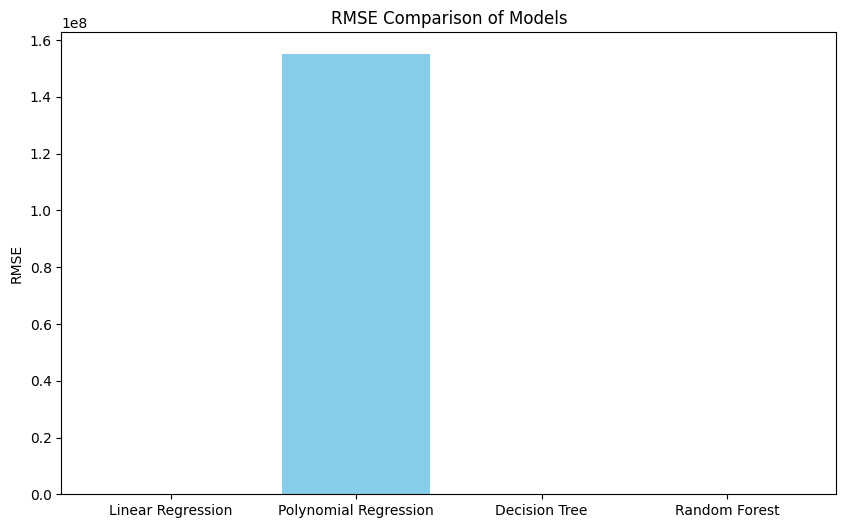

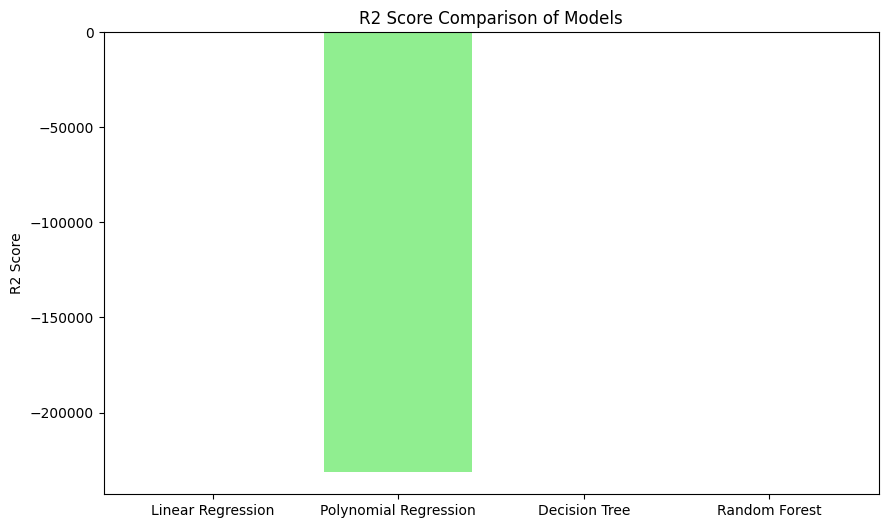

In [19]:
# Visualization
plt.figure(figsize=(10, 6))
plt.bar(models, rmse_values, color='skyblue')
plt.title("RMSE Comparison of Models")
plt.ylabel("RMSE")
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(models, r2_scores, color='lightgreen')
plt.title("R2 Score Comparison of Models")
plt.ylabel("R2 Score")
plt.show()

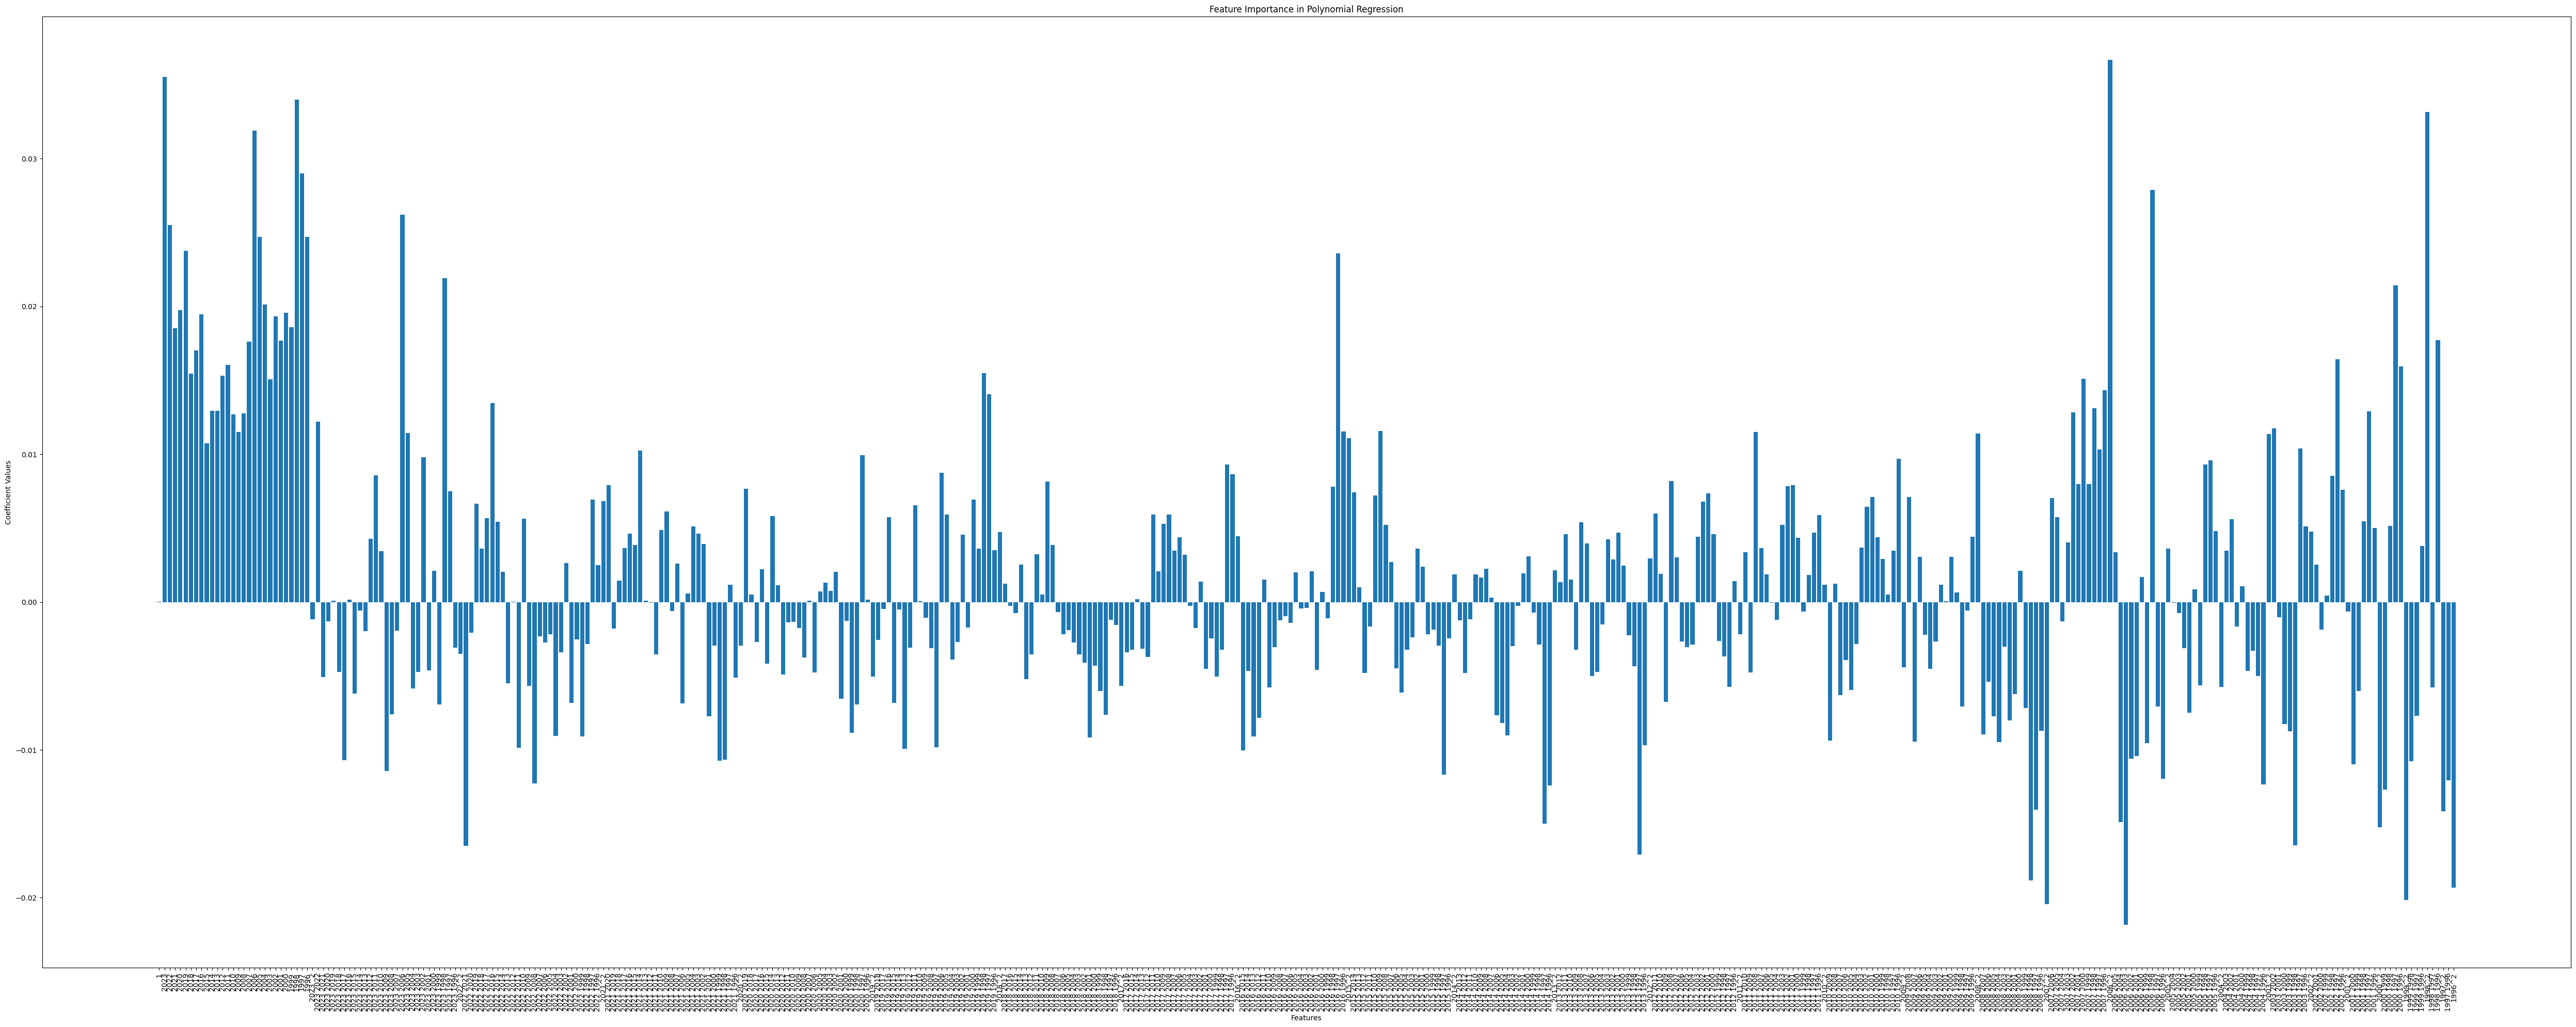

In [25]:
# Visualize feature importance (coefficients)
plt.figure(figsize=(50, 20))
coefficients = poly_model.coef_
feature_names = poly.get_feature_names_out(year_columns)
plt.bar(range(len(coefficients)), coefficients)
plt.xticks(range(len(coefficients)), feature_names, rotation=90)
plt.title("Feature Importance in Polynomial Regression")
plt.xlabel("Features")
plt.ylabel("Coefficient Values")
plt.tight_layout()
plt.show()